# Explainability

SHAP feature importance (global + per-customer) for LightGBM, followed by a
small GenAI demo that converts SHAP output into a plain-language explanation
for a non-technical stakeholder.

In [1]:
import pandas as pd
import shap
import matplotlib.pyplot as plt
from pathlib import Path

from churn.config import PROCESSED_DIR
from churn.modeling.train import get_xy, build_lightgbm
from churn.explainability.shap_analysis import fit_explainer, get_top_customers_by_risk, explain_customer

FIGURES_DIR = Path.cwd().parent / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(fig, name: str):
    fig.savefig(FIGURES_DIR / f"{name}.png", dpi=150, bbox_inches="tight")

train = pd.read_parquet(PROCESSED_DIR / "train_balanced.parquet")
test = pd.read_parquet(PROCESSED_DIR / "test_selected.parquet")
X_train, y_train = get_xy(train)
X_test, y_test = get_xy(test)

model = build_lightgbm().fit(X_train, y_train)
explainer = fit_explainer(model, X_train)

## Global feature importance (SHAP summary plot)

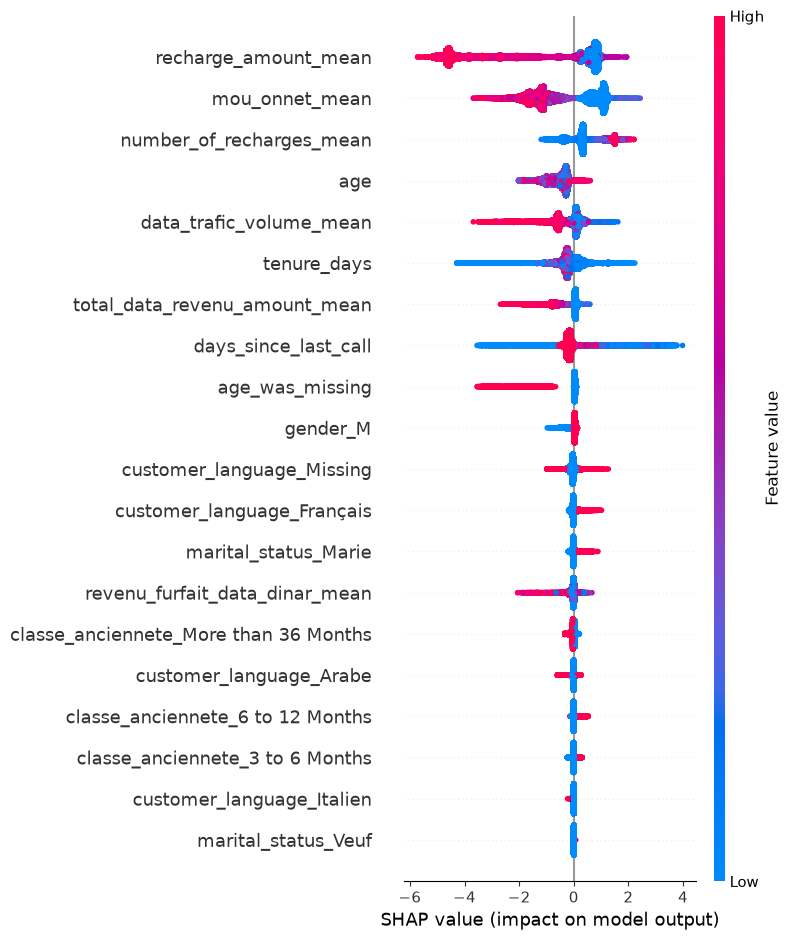

In [2]:
shap_values_test = explainer(X_test)

fig = plt.figure(figsize=(9, 8))
shap.summary_plot(shap_values_test, X_test, show=False)
plt.tight_layout()
save_fig(fig, "15_shap_summary")
plt.show()

## Per-customer explanation — example flagged customers

       predicted_proba
44566         0.988065
79984         0.984378
63625         0.983739
                                  feature     value  shap_value
7                             tenure_days        57    1.989141
0                    recharge_amount_mean  7.228388    1.312308
2                          mou_onnet_mean       0.0    1.100965
3                 data_trafic_volume_mean       0.0    0.594874
8                                     age      25.0   -0.568024
19        classe_anciennete_3 to 6 Months      True    0.306067
10                               gender_M      True    0.121829
21  classe_anciennete_More than 36 Months     False    0.120767
1                number_of_recharges_mean       1.0    0.097522
6                    days_since_last_call      91.0   -0.096218


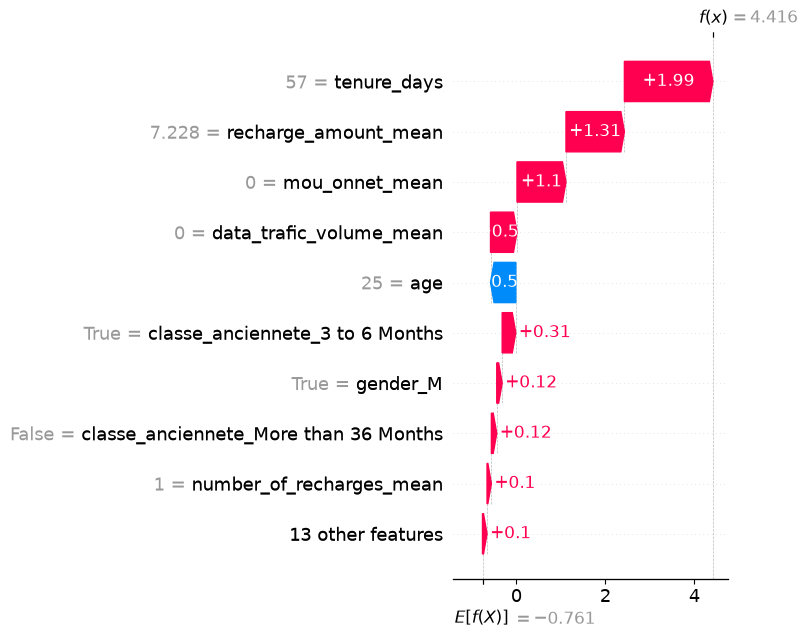

In [3]:
WORKING_THRESHOLD = 0.30  # LightGBM, 5:1 cost ratio, from step 9

top_customers = get_top_customers_by_risk(model, X_test, threshold=WORKING_THRESHOLD, n=3)
print(top_customers[["predicted_proba"]])

example_customer = X_test.loc[[top_customers.index[0]]]
customer_explanation = explain_customer(explainer, example_customer)
print(customer_explanation.head(10))

fig = plt.figure(figsize=(8, 6))
shap.plots.waterfall(explainer(example_customer)[0], show=False)
plt.tight_layout()
save_fig(fig, "16_shap_waterfall_example_customer")
plt.show()

## GenAI plain-language explanation (for non-technical stakeholders)

In [4]:
# Skipped: requires a paid ANTHROPIC_API_KEY not yet set up for this project.
# from churn.explainability.genai_explain import generate_explanation
#
# customer_proba = top_customers.iloc[0]["predicted_proba"]
# explanation = generate_explanation(customer_explanation, customer_proba)
# print(explanation)